# Student Dropout Prediction Project
## Notebook 06: Final Model Evaluation

This notebook brings together the modeling results and performs a final evaluation of the candidate models.

Two prediction stages are compared:
1. **Enrollment-only:** information available at enrollment.
2. **Semester 1:** enrollment information plus first-semester academic information.

The main metric is **Macro F1**, with Accuracy and Weighted F1 also reported. Macro F1 is used because the three target classes are not equally represented.


## 1. Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")


## 2. Load the prediction-stage datasets

In [2]:
enrollment_df = pd.read_csv("../data/processed/enrollment_only.csv")
semester1_df = pd.read_csv("../data/processed/semester1.csv")

X_enrollment = enrollment_df.drop(columns=["Target"])
y_enrollment = enrollment_df["Target"]
X_semester1 = semester1_df.drop(columns=["Target"])
y_semester1 = semester1_df["Target"]

print("Enrollment-only:", enrollment_df.shape)
print("Semester 1:", semester1_df.shape)


Enrollment-only: (4424, 25)
Semester 1: (4424, 31)


## 3. Define preprocessing

In [3]:
categorical_cols = [
    "Marital Status","Application mode","Application order","Course",
    "Daytime/evening attendance","Previous qualification",
    "Mother's qualification","Father's qualification",
    "Mother's occupation","Father's occupation","Displaced",
    "Educational special needs","Debtor","Tuition fees up to date",
    "Gender","Scholarship holder","International"
]

numerical_cols = [
    "Previous qualification (grade)","Admission grade","Age at enrollment"
]

semester1_numerical_cols = numerical_cols + [
    "Curricular units 1st sem (credited)",
    "Curricular units 1st sem (enrolled)",
    "Curricular units 1st sem (evaluations)",
    "Curricular units 1st sem (approved)",
    "Curricular units 1st sem (grade)",
    "Curricular units 1st sem (without evaluations)"
]

def make_preprocessor(num_cols):
    return ColumnTransformer([
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", StandardScaler(), num_cols)
    ])


## 4. Reproduce the stratified train-test split

In [4]:
X_train_en, X_test_en, y_train_en, y_test_en = train_test_split(
    X_enrollment, y_enrollment, test_size=0.20, random_state=42, stratify=y_enrollment
)
X_train_s1, X_test_s1, y_train_s1, y_test_s1 = train_test_split(
    X_semester1, y_semester1, test_size=0.20, random_state=42, stratify=y_semester1
)

print(len(X_train_en), len(X_test_en))
print(len(X_train_s1), len(X_test_s1))


3539 885
3539 885


## 5. Define models and tuning grids

In [5]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=300, random_state=42, n_jobs=-1
    )
}

grids = {
    "Logistic Regression": {
        "model__C": [0.1, 1.0, 10.0],
        "model__class_weight": [None, "balanced"]
    },
    "Decision Tree": {
        "model__max_depth": [None, 5, 10, 20],
        "model__min_samples_leaf": [1, 5, 10],
        "model__class_weight": [None, "balanced"]
    },
    "Random Forest": {
        "model__n_estimators": [200, 300],
        "model__max_depth": [None, 10, 20],
        "model__min_samples_leaf": [1, 5],
        "model__class_weight": [None, "balanced"]
    }
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


## 6. Tune and evaluate all candidate models

In [6]:
def run_model(stage, name, num_cols, Xtr, Xte, ytr, yte):
    pipe = Pipeline([
        ("preprocessor", make_preprocessor(num_cols)),
        ("model", models[name])
    ])
    search = GridSearchCV(
        pipe, grids[name], scoring="f1_macro", cv=cv, n_jobs=-1, refit=True
    )
    search.fit(Xtr, ytr)
    pred = search.predict(Xte)

    return {
        "Prediction Stage": stage,
        "Model": name,
        "Accuracy": accuracy_score(yte, pred),
        "Macro F1": f1_score(yte, pred, average="macro"),
        "Weighted F1": f1_score(yte, pred, average="weighted"),
        "CV Macro F1": search.best_score_,
        "Best Parameters": search.best_params_,
        "Estimator": search.best_estimator_,
        "Predictions": pred,
        "Y Test": yte
    }

results = []

for name in models:
    results.append(run_model(
        "Enrollment-only", name, numerical_cols,
        X_train_en, X_test_en, y_train_en, y_test_en
    ))

for name in models:
    results.append(run_model(
        "Semester 1", name, semester1_numerical_cols,
        X_train_s1, X_test_s1, y_train_s1, y_test_s1
    ))


## 7. Final model comparison

In [7]:
comparison_df = pd.DataFrame([
    {
        "Prediction Stage": r["Prediction Stage"],
        "Model": r["Model"],
        "Accuracy": r["Accuracy"],
        "Macro F1": r["Macro F1"],
        "Weighted F1": r["Weighted F1"],
        "CV Macro F1": r["CV Macro F1"]
    }
    for r in results
])

display(comparison_df)


,Prediction Stage,Model,Accuracy,Macro F1,Weighted F1,CV Macro F1
0,Enrollment-only,Logistic Regression,0.5627,0.5359,0.5805,0.5638
1,Enrollment-only,Decision Tree,0.5107,0.5033,0.5382,0.5125
2,Enrollment-only,Random Forest,0.5864,0.5432,0.5947,0.5726
3,Semester 1,Logistic Regression,0.7107,0.6732,0.7238,0.6770
4,Semester 1,Decision Tree,0.6056,0.5905,0.6365,0.6253
5,Semester 1,Random Forest,0.7096,0.6521,0.7129,0.6856


## 8. Cross-validation versus held-out test performance

In [8]:
cv_test = comparison_df[
    ["Prediction Stage", "Model", "CV Macro F1", "Macro F1"]
].copy()
cv_test["CV-Test Difference"] = cv_test["Macro F1"] - cv_test["CV Macro F1"]
display(cv_test)


,Prediction Stage,Model,CV Macro F1,Macro F1,CV-Test Difference
0,Enrollment-only,Logistic Regression,0.5638,0.5359,-0.0279
1,Enrollment-only,Decision Tree,0.5125,0.5033,-0.0092
2,Enrollment-only,Random Forest,0.5726,0.5432,-0.0294
3,Semester 1,Logistic Regression,0.6770,0.6732,-0.0038
4,Semester 1,Decision Tree,0.6253,0.5905,-0.0348
5,Semester 1,Random Forest,0.6856,0.6521,-0.0334


## 9. Classification reports

In [9]:
for r in results:
    print("=" * 80)
    print(r["Prediction Stage"], "|", r["Model"])
    print("=" * 80)
    print(classification_report(r["Y Test"], r["Predictions"], digits=4))


Enrollment-only | Logistic Regression
              precision    recall  f1-score   support

     Dropout     0.6549    0.5880    0.6197       284
    Enrolled     0.2778    0.4717    0.3497       159
    Graduate     0.7111    0.5792    0.6384       442

    accuracy                         0.5627       885
   macro avg     0.5479    0.5463    0.5359       885
weighted avg     0.6152    0.5627    0.5805       885

Enrollment-only | Decision Tree
              precision    recall  f1-score   support

     Dropout     0.6476    0.4789    0.5506       284
    Enrolled     0.2590    0.6352    0.3679       159
    Graduate     0.7544    0.4864    0.5915       442

    accuracy                         0.5107       885
   macro avg     0.5537    0.5335    0.5033       885
weighted avg     0.6311    0.5107    0.5382       885

Enrollment-only | Random Forest
              precision    recall  f1-score   support

     Dropout     0.6300    0.6056    0.6176       284
    Enrolled     0.3024    

## 10. Confusion matrices

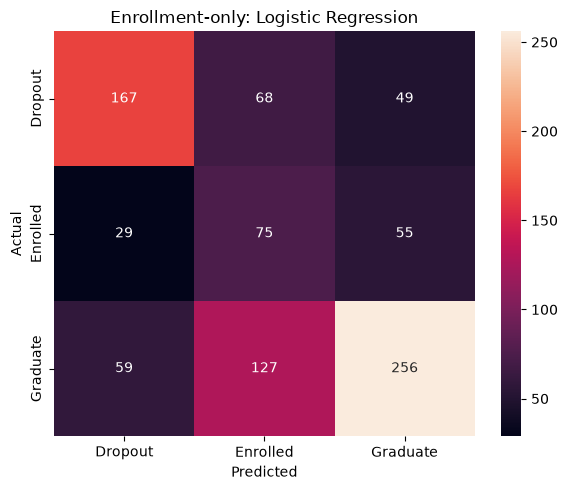

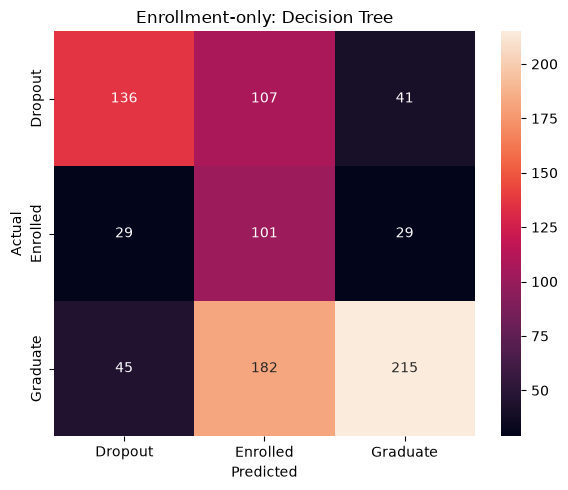

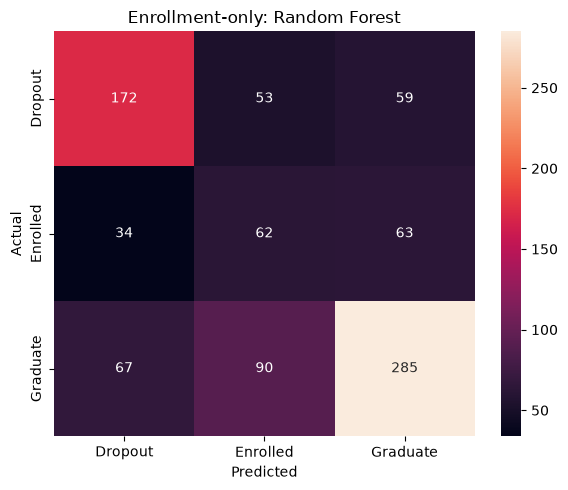

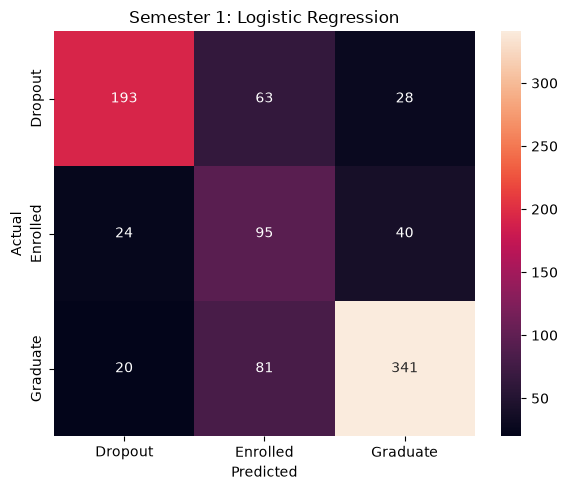

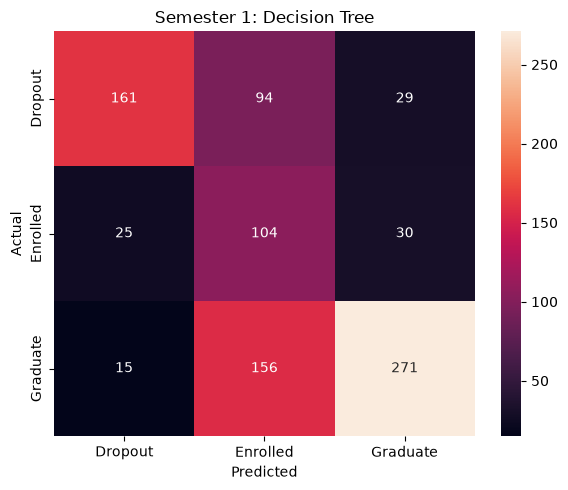

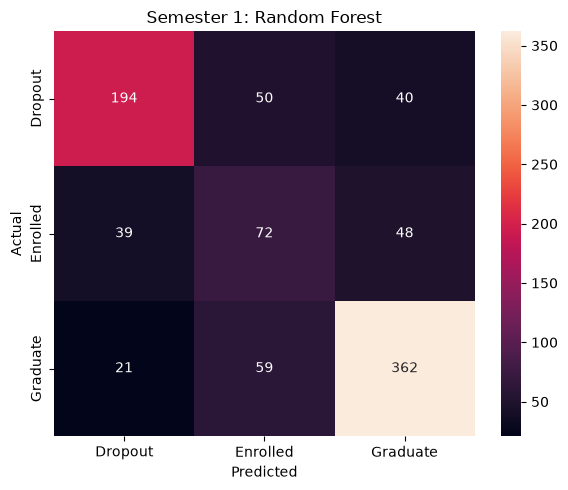

In [10]:
for r in results:
    cm = confusion_matrix(
        r["Y Test"], r["Predictions"],
        labels=["Dropout", "Enrolled", "Graduate"]
    )
    plt.figure(figsize=(6,5))
    sns.heatmap(
        cm, annot=True, fmt="d",
        xticklabels=["Dropout","Enrolled","Graduate"],
        yticklabels=["Dropout","Enrolled","Graduate"]
    )
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f'{r["Prediction Stage"]}: {r["Model"]}')
    plt.tight_layout()
    plt.show()


## 11. Compare prediction stages

In [11]:
stage_comparison = comparison_df.pivot(
    index="Model",
    columns="Prediction Stage",
    values=["Accuracy", "Macro F1", "Weighted F1"]
)
display(stage_comparison)

changes = []
for name in models:
    en = comparison_df[
        (comparison_df["Prediction Stage"]=="Enrollment-only") &
        (comparison_df["Model"]==name)
    ].iloc[0]
    s1 = comparison_df[
        (comparison_df["Prediction Stage"]=="Semester 1") &
        (comparison_df["Model"]==name)
    ].iloc[0]
    changes.append({
        "Model": name,
        "Accuracy Change": s1["Accuracy"] - en["Accuracy"],
        "Macro F1 Change": s1["Macro F1"] - en["Macro F1"],
        "Weighted F1 Change": s1["Weighted F1"] - en["Weighted F1"]
    })

display(pd.DataFrame(changes))


Accuracy                   Macro F1             \
Prediction Stage    Enrollment-only Semester 1 Enrollment-only Semester 1   
Model                                                                       
Decision Tree                0.5107     0.6056          0.5033     0.5905   
Logistic Regression          0.5627     0.7107          0.5359     0.6732   
Random Forest                0.5864     0.7096          0.5432     0.6521   

                        Weighted F1             
Prediction Stage    Enrollment-only Semester 1  
Model                                           
Decision Tree                0.5382     0.6365  
Logistic Regression          0.5805     0.7238  
Random Forest                0.5947     0.7129

,Model,Accuracy Change,Macro F1 Change,Weighted F1 Change
0,Logistic Regression,0.1480,0.1373,0.1433
1,Decision Tree,0.0949,0.0871,0.0983
2,Random Forest,0.1232,0.1089,0.1182


## 12. Save final comparison

In [12]:
comparison_df.to_csv(
    "../data/processed/final_model_comparison.csv", index=False
)
print("Saved: data/processed/final_model_comparison.csv")


Saved: data/processed/final_model_comparison.csv


## 13. Findings

### Finding 1: Overall model performance

The enrollment-only models achieved Macro F1 scores between 0.5033 and 0.5432. The Semester 1 models achieved higher Macro F1 scores, ranging from 0.5905 to 0.6732. This shows that prediction performance changed substantially when first-semester academic information was included.

### Finding 2: Prediction stage

Adding first-semester academic information increased Macro F1 for all three models. The change was +0.1373 for Logistic Regression, +0.0871 for Decision Tree, and +0.1089 for Random Forest. The corresponding changes in accuracy were also positive for all three models.

### Finding 3: Class-level performance

The Semester 1 Logistic Regression classification report shows that Dropout and Graduate were identified with higher F1 scores than Enrolled. The F1 scores were 0.7409 for Dropout, 0.4774 for Enrolled, and 0.8014 for Graduate. The Enrolled class therefore remained more difficult to identify accurately.

### Finding 4: Cross-validation and test performance

The cross-validation and held-out test Macro F1 values were relatively close for the evaluated models. For example, Semester 1 Logistic Regression achieved a CV Macro F1 of 0.6770 and a test Macro F1 of 0.6732. Semester 1 Random Forest achieved a CV Macro F1 of 0.6856 and a test Macro F1 of 0.6521. This provides a comparison between the cross-validation estimate and performance on the held-out test set.

### Finding 5: Interpretation

The results show that the information available at the prediction stage is important for predictive performance. First-semester academic information provides additional predictive information compared with enrollment-only data. However, these results describe predictive relationships within this dataset and do not establish that any individual variable causes a student's outcome.

## 14. Project conclusion

The final project conclusion should answer:

1. Can student outcomes be predicted using information available at enrollment?
2. Does predictive performance change when first-semester academic information becomes available?
3. Which target classes remain difficult to identify?

The conclusion should report the actual metrics rather than relying on a single accuracy value.
